# Скринер юниверса: hard cut по cap\*

**Трек 2** (research). Канон — одна колонка `take` в [`bybit_okx_universe.csv`](../bybit_okx_universe.csv).

## Метод

1. Юниверс Bybit ∩ OKX, фьючи на акции / ETF / металлы — `is_crypto` (denylist).
2. Капитализация — кэш CoinGecko. Августовское СКО спреда — кэш lean ticks  
   (`std_spread = max(sample_std(long), sample_std(short))`, проценты,  
   окно **2026-08-03T13:35Z … 2026-08-27T11:40Z**). Тики заново не сканируем.
3. На plot-set с usable СКО: `ln(std_spread) = a + b · ln(cap)` (`np.polyfit`).
4. Один порог: эмпирический **Q25** `std_spread` → инверсия OLS → **cap\***.
5. **Hard cut:** `take = no`, если equity, нет cap, или `cap > cap\*`; иначе `yes`.

Q25 задаёт только cap\*, не второй нож по СКО. Тихие мелкие остаются (август мог быть сонным). Монеты без СКО, но с cap ≤ cap\* (девять Z\*) — `yes`.

Коротко про отброшенное: смотрели оборот~cap, жёсткие $200M по p99 и AND «тихо ∧ крупно». Канон заменили на hard cap\* — в шумных гигантах нет потенциала.

Это экран тиков, не PnL.

In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO = Path("..").resolve()
if not (REPO / "research" / "universe_liquidity_lib.py").exists():
    REPO = Path.cwd().resolve()
sys.path.insert(0, str(REPO))

import research.universe_liquidity_lib as ull

ull = importlib.reload(ull)
from research.is_crypto import DEFAULT_DENYLIST_PATH
from research.universe_liquidity_lib import (
    DEFAULT_UNIVERSE,
    JOINT_STD_QUANTILE,
    METRICS_CSV,
    VOL_STD_CSV,
    VOL_WINDOW_END,
    VOL_WINDOW_START,
    assign_take_yes_no,
    compute_august_spread_std,
    fit_loglog_ols_xy,
    join_august_spread_std,
    joint_threshold_from_ols,
    load_universe,
    split_crypto_equity,
    write_universe_take_column,
)

print("REPO", REPO)
print("юниверс", DEFAULT_UNIVERSE)
print("окно СКО", VOL_WINDOW_START, "…", VOL_WINDOW_END)
print("denylist", DEFAULT_DENYLIST_PATH)


REPO /Users/mishatrubik/Desktop/spread
юниверс /Users/mishatrubik/Desktop/spread/bybit_okx_universe.csv
окно СКО 2026-08-03T13:35:00Z … 2026-08-27T11:40:00Z
denylist /Users/mishatrubik/Desktop/spread/research/data/non_crypto_base_coins.txt


In [2]:
universe = load_universe(DEFAULT_UNIVERSE)
crypto, equity = split_crypto_equity(universe)
metrics = pd.read_csv(METRICS_CSV)
std_df = compute_august_spread_std(force=False)
joined = join_august_spread_std(metrics, std_df)

cloud = joined.loc[
    joined["in_plot_set"].astype(bool)
    & joined["std_usable"].fillna(False)
    & np.isfinite(pd.to_numeric(joined["market_cap_usd"], errors="coerce"))
    & (pd.to_numeric(joined["market_cap_usd"], errors="coerce") > 0)
    & np.isfinite(pd.to_numeric(joined["std_spread"], errors="coerce"))
    & (pd.to_numeric(joined["std_spread"], errors="coerce") > 0)
].copy()

ols = fit_loglog_ols_xy(cloud, y_col="std_spread", y_name="std_spread")
spec = joint_threshold_from_ols(cloud, q=JOINT_STD_QUANTILE, ols=ols)

print(f"юниверс {len(universe)}  crypto {len(crypto)}  equity {len(equity)}")
print(f"plot-set {int(joined['in_plot_set'].astype(bool).sum())}  OLS n={ols['n']}")
print("единицы std_spread: проценты")
print(ols["equation"], f"R²={ols['r2']:.4f}")
print(f"Q25 = {spec['q_std']:.6f} %")
print(f"cap* = ${spec['cap_star_usd']:,.0f}")
print(f"проверка OLS(cap*) = {spec['pred_std_at_cap_star']:.6f} %")
print("кэш СКО", VOL_STD_CSV)
print("кэш cap", METRICS_CSV)


юниверс 345  crypto 249  equity 96
plot-set 241  OLS n=232
единицы std_spread: проценты
log(std_spread) = 1.1501 + -0.2026 * log(cap) R²=0.4728
Q25 = 0.051699 %
cap* = $653,682,245
проверка OLS(cap*) = 0.051699 %
кэш СКО /Users/mishatrubik/Desktop/spread/research/data/universe_spread_std_august.csv
кэш cap /Users/mishatrubik/Desktop/spread/research/data/universe_liquidity_metrics.csv


In [3]:
cap_by_coin = {}
for _, r in joined.iterrows():
    cap = pd.to_numeric(r["market_cap_usd"], errors="coerce")
    if pd.notna(cap) and np.isfinite(cap) and float(cap) > 0:
        cap_by_coin[str(r["base_coin"]).strip().upper()] = float(cap)

take = assign_take_yes_no(
    universe, cap_star_usd=spec["cap_star_usd"], cap_by_coin=cap_by_coin
)
universe = universe.assign(take=take)
n_yes = int((take == "yes").sum())
n_no = int((take == "no").sum())
print(f"take  yes={n_yes}  no={n_no}  total={len(take)}")

eq_set = set(equity["base_coin"])
equity_no = int(((universe["base_coin"].isin(eq_set)) & (take == "no")).sum())
has_cap = universe["base_coin"].map(cap_by_coin)
capstar_no = int((has_cap.notna() & (has_cap > spec["cap_star_usd"]) & (take == "no") & ~universe["base_coin"].isin(eq_set)).sum())
miss_no = int((has_cap.isna() & (take == "no") & ~universe["base_coin"].isin(eq_set)).sum())
print(f"  no: equity {equity_no}  cap>cap* {capstar_no}  нет cap {miss_no}")

zstar = ["LRC", "ZEN", "ZETA", "ZIL", "ZK", "ZKP", "ZORA", "ZRO", "ZRX"]
z_yes = universe.loc[universe["base_coin"].isin(zstar), ["base_coin", "take"]]
print("Z* (не было августовского СКО, cap-only):")
display(z_yes)


take  yes=198  no=147  total=345
  no: equity 96  cap>cap* 43  нет cap 8
Z* (не было августовского СКО, cap-only):


,base_coin,take
178,LRC,yes
337,ZEN,yes
338,ZETA,yes
339,ZIL,yes
340,ZK,yes
341,ZKP,yes
342,ZORA,yes
343,ZRO,yes
344,ZRX,yes


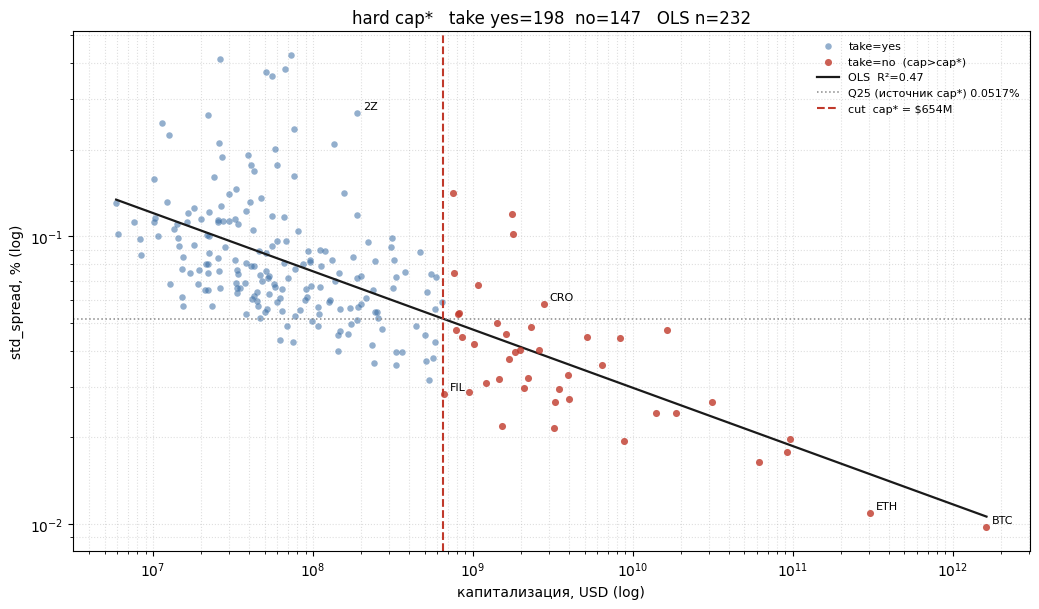

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 6.2))
x = cloud["market_cap_usd"].to_numpy(dtype=float)
y = cloud["std_spread"].to_numpy(dtype=float)
take_cloud = cloud["base_coin"].map(
    dict(zip(universe["base_coin"], universe["take"]))
)
yes = take_cloud.eq("yes").to_numpy()
ax.scatter(x[yes], y[yes], s=22, c="#3b6ea5", alpha=0.55, linewidths=0, zorder=2, label="take=yes")
ax.scatter(x[~yes], y[~yes], s=26, c="#c0392b", alpha=0.8, linewidths=0, zorder=3, label="take=no  (cap>cap*)")

grid = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
ax.plot(grid, np.exp(ols["a"] + ols["b"] * np.log(grid)),
        color="#1a1a1a", lw=1.6, label=f"OLS  R²={ols['r2']:.2f}")
ax.axhline(spec["q_std"], color="#888", ls=":", lw=1.1, label=f"Q25 (источник cap*) {spec['q_std']:.4f}%")
ax.axvline(spec["cap_star_usd"], color="#c0392b", ls="--", lw=1.5,
           label=f"cut  cap* = ${spec['cap_star_usd']/1e6:.0f}M")

for _, r in cloud.loc[cloud["base_coin"].isin(["BTC", "ETH", "2Z", "FIL", "CRO"])].iterrows():
    ax.annotate(r["base_coin"], (r["market_cap_usd"], r["std_spread"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("капитализация, USD (log)")
ax.set_ylabel("std_spread, % (log)")
ax.set_title(f"hard cap*   take yes={n_yes}  no={n_no}   OLS n={ols['n']}")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig_dir = REPO / "research" / "data" / "universe_liquidity_cache" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "scatter_capstar_hard_cut.png", dpi=140, bbox_inches="tight")
display(fig)
plt.close(fig)


In [5]:
take_map = dict(zip(universe["base_coin"].astype(str).str.upper(), universe["take"]))
written = write_universe_take_column(take_map, path=DEFAULT_UNIVERSE)
check = pd.read_csv(DEFAULT_UNIVERSE)
print("записано", DEFAULT_UNIVERSE)
print(written)
print("колонки", list(check.columns))
print("строк", len(check), "take", check["take"].value_counts().to_dict())
assert len(check) == len(universe) == 345
assert list(check.columns)[-1] == "take"
assert set(check["take"]) <= {"yes", "no"}
assert written["yes"] == n_yes and written["no"] == n_no
print("ok: 345 строк, take последняя, yes/no совпали.")


записано /Users/mishatrubik/Desktop/spread/bybit_okx_universe.csv
{'n': 345, 'yes': 198, 'no': 147, 'ncols': 11}
колонки ['base_coin', 'okx_symbol', 'bybit_symbol', 'okx_tick_size', 'okx_lot_size', 'okx_min_size', 'bybit_tick_size', 'bybit_qty_step', 'bybit_min_order_qty', 'bybit_min_notional_value', 'take']
строк 345 take {'yes': 198, 'no': 147}
ok: 345 строк, take последняя, yes/no совпали.
